In [17]:
# Import library dasar yang di gunakan sepanjang project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

Pada tahap ini, dilakukan proses **import library** yang akan digunakan secara keseluruhan mulai dari eksplorasi data, pembuatan model, hingga persiapan *deployment*.

1. **Manipulasi & Visualisasi Data:**
- `pandas` digunakan untuk manipulasi dan analisis data dalam bentuk DataFrame.
- `numpy` digunakan untuk komputasi numerik tingkat lanjut.
- `matplotlib.pyplot` dan `seaborn` digunakan untuk membuat visualisasi grafik yang menarik dan informatif pada tahap *Exploratory Data Analysis* (EDA).

2. **Algoritma Machine Learning (Scikit-Learn):**
- `LogisticRegression`, `DecisionTreeClassifier`, `RandomForestClassifier`, `GradientBoostingClassifier`, dan `KNeighborsClassifier` adalah algoritma yang digunakan untuk membangun dan membandingkan model prediksi klasifikasi.

3. **Persiapan & Evaluasi Model (Scikit-Learn):**
- `train_test_split` digunakan untuk memecah dataset menjadi data latih (*training*) dan data uji (*testing*).
- `StandardScaler` digunakan pada tahap preprocessing untuk menyamakan skala fitur numerik (*feature scaling*).
- `accuracy_score` dan `f1_score` digunakan sebagai metrik untuk mengukur dan mengevaluasi seberapa akurat performa prediksi model.
- `GridSearchCV` digunakan untuk melakukan *Hyperparameter Tuning*, yaitu mencari parameter algoritma terbaik secara otomatis.

4. **Ekspor Model:**  
- `joblib` digunakan untuk menyimpan (*export*) model yang sudah dilatih, *scaler*, dan daftar fitur ke dalam bentuk file fisik (seperti `.pkl`) agar bisa digunakan pada aplikasi web Streamlit.

In [18]:
# Menghubungkan Google Colab dengan Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Kode ini berfungsi untuk menyambungkan ruang kerja Google Colab dengan akun Google Drive. Proses **mounting** ini wajib dilakukan agar Colab dapat mengakses dan membaca file dataset `.csv` yang telah di simpan di dalam folder Google Drive.

In [19]:
# Path menuju file dataset di Google Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/FastTrack_BengkelKoding/Bengkod-Depresi.csv'

# Membaca data csv ke dalam dataframe pandas
df = pd.read_csv(file_path)

# Menampilkan 5 baris pertama untuk memastikan data berhasil di-load
display(df.head())

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1.0
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0.0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0.0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1.0
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0.0


Pada sel ini, dataset dimuat dari direktori Google Drive ke dalam variabel `df` menggunakan fungsi `pd.read_csv()` milik library pandas. Selanjutnya, fungsi `display(df.head())` dipanggil untuk menampilkan 5 baris teratas dari dataset. Tujuannya adalah untuk memverifikasi bahwa data telah terbaca dengan format kolom yang benar sebelum dianalisis lebih lanjut.

In [20]:
# Menampilkan informasi ringkas tentang kolom dan tipe data
print("----- Info Dataset -----")
df.info()

----- Info Dataset -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28008 entries, 0 to 28007
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     28008 non-null  int64  
 1   Gender                                 28008 non-null  object 
 2   Age                                    28008 non-null  int64  
 3   City                                   28008 non-null  object 
 4   Profession                             28008 non-null  object 
 5   Academic Pressure                      28008 non-null  int64  
 6   Work Pressure                          28008 non-null  int64  
 7   CGPA                                   28008 non-null  float64
 8   Study Satisfaction                     28008 non-null  int64  
 9   Job Satisfaction                       28008 non-null  int64  
 10  Sleep Duration                         28008 

Fungsi `df.info()` digunakan untuk memeriksa karakteristik awal dataset. Hasil eksekusi akan menampilkan jumlah total baris, daftar nama kolom, jumlah data yang tidak kosong **(non-null count)**, serta tipe data masing-masing kolom (numerik atau teks). Informasi ini merupakan fondasi penting untuk menentukan langkah *preprocessing* data (seperti penanganan *missing value* atau konversi tipe data) pada tahap selanjutnya.

# Membuat EDA (Exploratory Data Analysis)

In [21]:
# Membersihkan missing values pada variabel target
df = df.dropna(subset=['Depression'])

# Mengubah tipe data target menjadi integer (dari float64 ke int64)
df['Depression'] = df['Depression'].astype(int)

print(f"Jumlah baris setelah pembersihan target: {len(df)}")

Jumlah baris setelah pembersihan target: 27966


**Data Cleaning Awal**: Sebelum melakukan visualisasi, baris data yang tidak memiliki nilai pada kolom target `Depression` dihapus. Hal ini krusial karena model *machine learning* tidak bisa belajar dari target yang kosong. Selain itu, tipe data target diubah dari `float` menjadi `integer` (0 dan 1) untuk memudahkan proses klasifikasi.

/tmp/ipykernel_2522/4025950274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Depression', palette='Set2')


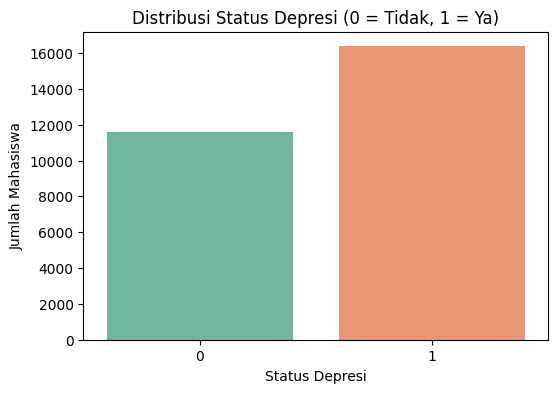

Depression
1    58.535364
0    41.464636
Name: proportion, dtype: float64


In [22]:
# INSIGHT 1: Distribusi Variabel Target (Depression)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Depression', palette='Set2')
plt.title('Distribusi Status Depresi (0 = Tidak, 1 = Ya)')
plt.xlabel('Status Depresi')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

# Menampilkan persentase
print(df['Depression'].value_counts(normalize=True) * 100)

**Insight 1: Proporsi Keseimbangan Kelas Target**  
Berdasarkan visualisasi dan perhitungan persentase, dataset ini memiliki distribusi target yang cukup seimbang (*mildly imbalanced*), yaitu sekitar 58.5% mahasiswa mengalami depresi (1) dan 41.5% tidak depresi (0).

**Keputusan untuk tahap selanjutnya:**  
Karena rasio 60:40 ini masih tergolong seimbang, maka tidak perlu melakukan teknik penyeimbangan data yang rumit (seperti SMOTE). Namun, pada tahap evaluasi model nanti, akan tetap menggunakan metrik *F1-Score* dan *Recall* bersama dengan Akurasi untuk memastikan model tidak bias dalam memprediksi kelas mayoritas.

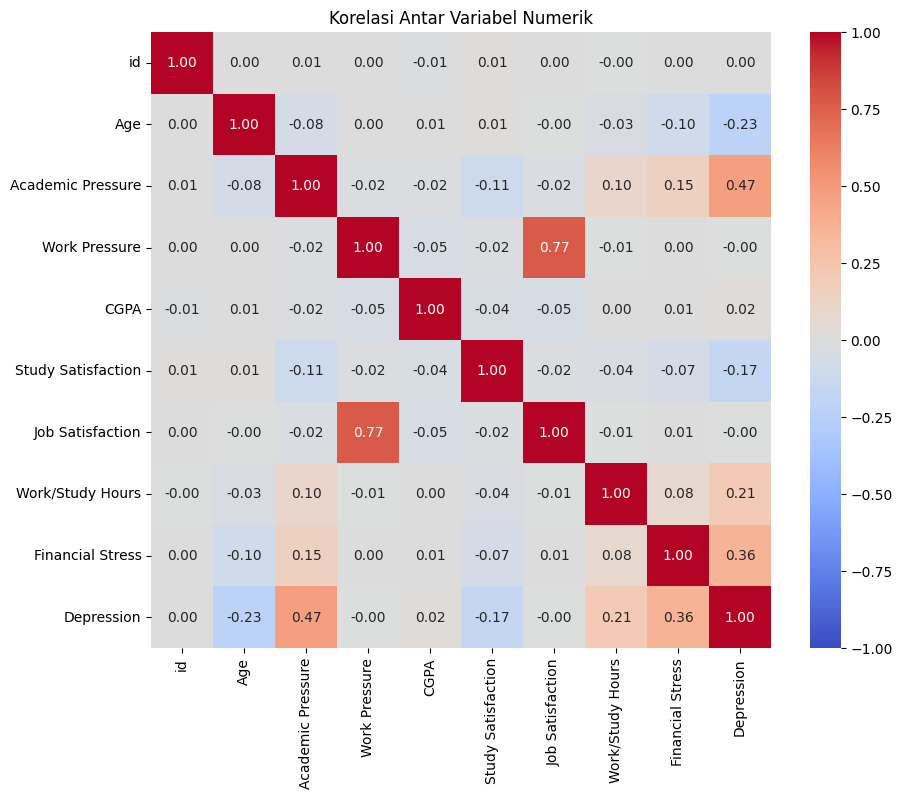

In [23]:
# INSIGHT 2: Korelasi Fitur Numerik terhadap Depresi
# Memilih hanya kolom numerik
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(10, 8))
# Menghitung korelasi dan memvisualisasikannya dengan Heatmap
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Korelasi Antar Variabel Numerik')
plt.show()

**Insight 2: Hubungan Fitur Numerik terhadap Status Depresi**  
Visualisasi *Heatmap* menunjukkan nilai korelasi antar variabel. Terlihat bahwa fitur `Academic Pressure` (0.47) dan `Financial Stress` (0.36) memiliki korelasi positif yang cukup kuat dengan tingkat depresi. Sebaliknya, fitur seperti `id` (0.00), `Work Pressure` (0.00), dan `CGPA` (0.02) memiliki korelasi yang nyaris nol terhadap status depresi.

**Keputusan untuk tahap selanjutnya:**  
Pada tahap *Feature Selection* dan *Preprocessing*, fitur `id` wajib dihapus (di-*drop*) karena hanya sekadar nomor urut dan tidak memiliki nilai prediktif. Fitur lain dengan korelasi mendekati nol juga menjadi kandidat kuat untuk dieliminasi agar model menjadi lebih ringan dan fokus pada variabel yang benar-benar berpengaruh.

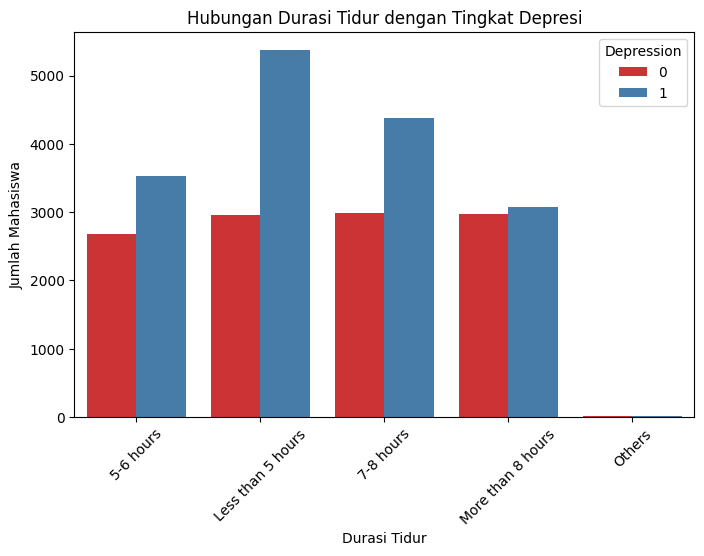

In [24]:
# INSIGHT 3: Pengaruh Durasi Tidur terhadap Depresi (Analisis Fitur Kategorikal)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Sleep Duration', hue='Depression', palette='Set1')
plt.title('Hubungan Durasi Tidur dengan Tingkat Depresi')
plt.xlabel('Durasi Tidur')
plt.ylabel('Jumlah Mahasiswa')
plt.xticks(rotation=45)
plt.show()

**Insight 3: Pola Gaya Hidup (Kategorikal) dan Risiko Depresi**  
Grafik *Countplot* menunjukkan bahwa durasi tidur berkorelasi erat dengan depresi. Kategori "Less than 5 hours" memiliki lonjakan jumlah mahasiswa depresi yang paling drastis dibandingkan yang tidak depresi. Hal ini membuktikan bahwa variabel pola tidur sangat krusial.

**Keputusan untuk tahap selanjutnya:**  
Karena model *machine learning* tidak bisa membaca teks seperti "Less than 5 hours", kolom `Sleep Duration` (beserta kolom teks lainnya seperti `Dietary Habits` dan `Gender`) harus diubah menjadi angka pada tahap *Preprocessing* menggunakan metode *Encoding* (seperti *Label Encoding* atau *One-Hot Encoding*).

# Direct Modeling

In [25]:
# Membersihkan sisa missing values (NaN) pada seluruh kolom fitur agar model tidak error saat tahap training
df_clean = df.dropna()

# Memisahkan fitur (X) dan target (y)
# Kolom 'id' di buang berdasarkan temuan Insight 2 di EDA
X = df_clean.drop(columns=['Depression', 'id'])
y = df_clean['Depression']

# BARE-MINIMUM ENCODING: Mengubah kolom teks menjadi kolom numerik biner (0 dan 1)
X_encoded = pd.get_dummies(X, drop_first=True)

# Membagi data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih: {X_train.shape[0]} baris")
print(f"Jumlah data uji: {X_test.shape[0]} baris")

Jumlah data latih: 22370 baris
Jumlah data uji: 5593 baris


**Persiapan Direct Modeling:**  
Pada tahap ini, variabel target `Depression` dipisahkan dari variabel fitur. Kolom `id` dihapus secara permanen karena terbukti tidak memiliki korelasi pada tahap EDA. Mengingat Scikit-Learn memerlukan input numerik, diterapkan `pd.get_dummies()` sebagai langkah darurat (*bare-minimum encoding*) untuk mengubah data kategorikal menjadi numerik biner. Terakhir, data dipecah menjadi 80% untuk pelatihan model (*training*) dan 20% untuk pengujian (*testing*).

In [26]:
# Inisialisasi 5 model ke dalam sebuah dictionary
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest (Ensemble)": RandomForestClassifier(random_state=42),
    "Gradient Boosting (Ensemble)": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier()
}

# Dictionary/List untuk menyimpan hasil evaluasi
results = []

# Melatih (fit) dan mengevaluasi setiap model secara otomatis menggunakan perulangan (loop)
for name, model in models.items():
    # Model belajar dari data latih
    model.fit(X_train, y_train)

    # Model menebak data uji
    y_pred = model.predict(X_test)

    # Menghitung skor
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Menyimpan hasil
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})

# Menampilkan hasil komparasi model dalam bentuk tabel
df_results = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
display(df_results)

,Model,Accuracy,F1-Score
0,Logistic Regression,0.843912,0.868623
3,Gradient Boosting (Ensemble),0.841588,0.866647
2,Random Forest (Ensemble),0.839442,0.865084
4,K-Nearest Neighbors (KNN),0.803504,0.836774
1,Decision Tree,0.773824,0.806130


**Hasil Direct Modeling & Alasan Pemilihan Model:**  
Tahap ini bertujuan untuk menetapkan nilai acuan (*baseline*) sebelum *preprocessing* mendalam dilakukan. Lima model yang dipilih dan alasan logis pemilihannya adalah:  

1. **Logistic Regression:**  
Dipilih sebagai standar model linear paling dasar dan ringan untuk klasifikasi biner.

2. **Decision Tree:**  
Dipilih sebagai model non-linear dasar yang sangat mudah diinterpretasikan aturan keputusannya.

3. **Random Forest (Ensemble):**  
Dipilih karena kemampuannya yang sangat baik (*robust*) dalam menangani data mentah (tanpa *scaling*) melalui teknik *bagging* (menggabungkan banyak *Decision Tree*).

4. **Gradient Boosting (Ensemble):**  
Dipilih sebagai perwakilan teknik *boosting* yang terbukti secara matematis mampu menghasilkan akurasi tertinggi pada data tabular.

5. **K-Nearest Neighbors (KNN):**  
Dipilih sebagai model berbasis metrik jarak (*instance-based*) untuk melihat bagaimana data mentah saling berdekatan dalam ruang dimensi yang ada.

*Catatan evaluasi: Tabel di atas menampilkan metrik Akurasi dan F1-Score yang murni didapat dari kondisi data mentah (direct modeling), yang nantinya akan dikomparasi dengan hasil setelah tahap Preprocessing.*

# Modeling Dengan Preprocessing

In [27]:
# Inisialisasi metode scaling
scaler = StandardScaler()

# PREPROCESSING: Menerapkan scaling pada data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dictionary untuk menyimpan hasil setelah preprocessing
results_preprocessed = []

# Melatih ulang ke-5 model menggunakan data yang sudah bersih dan di-scale
for name, model in models.items():
    # Model belajar dari data latih yang sudah di-scaling
    model.fit(X_train_scaled, y_train)

    # Model menebak data uji yang sudah di-scaling
    y_pred_scaled = model.predict(X_test_scaled)

    # Menghitung skor
    acc = accuracy_score(y_test, y_pred_scaled)
    f1 = f1_score(y_test, y_pred_scaled)

    # Menyimpan hasil
    results_preprocessed.append({
        "Model": name,
        "Accuracy (Scaled)": acc,
        "F1-Score (Scaled)": f1
    })

# Menampilkan hasil komparasi model setelah preprocessing
df_results_pre = pd.DataFrame(results_preprocessed).sort_values(by="Accuracy (Scaled)", ascending=False)

print("--- HASIL MODELING DENGAN PREPROCESSING ---")
display(df_results_pre)

--- HASIL MODELING DENGAN PREPROCESSING ---


,Model,Accuracy (Scaled),F1-Score (Scaled)
0,Logistic Regression,0.842660,0.867550
3,Gradient Boosting (Ensemble),0.841588,0.866647
2,Random Forest (Ensemble),0.838906,0.864654
1,Decision Tree,0.773467,0.805705
4,K-Nearest Neighbors (KNN),0.718756,0.775382


**Tahap Preprocessing & Evaluasi Ulang:**  
Pada tahap ini, diterapkan teknik *Feature Scaling* menggunakan `StandardScaler`. Tujuannya adalah menormalkan rentang nilai (*range*) dari seluruh fitur numerik agar memiliki rata-rata 0 dan standar deviasi 1. Hal ini sangat krusial agar model algoritma (terutama berbasis jarak seperti KNN atau linear seperti Logistic Regression) tidak memberikan bobot berlebih pada fitur yang memiliki angka absolut besar (seperti `Age` atau durasi jam) dibandingkan fitur berangka kecil (seperti `CGPA`).

*Catatan Penting: Proses fit dari scaler hanya dilakukan secara eksklusif pada data latih (X_train) untuk menghindari kebocoran informasi (Data Leakage). Setelah itu, aturan penskalaan tersebut diaplikasikan (transform) pada data uji (X_test). Hasil tabel menunjukkan performa model setelah data distandarisasi.*

# Feature Selection

/tmp/ipykernel_2522/4281908828.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importances.head(10), x='Kepentingan', y='Fitur', palette='viridis')


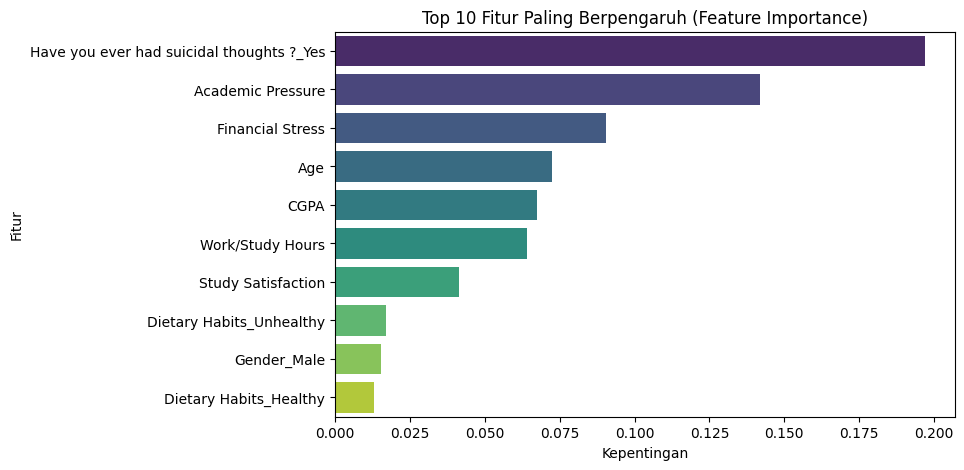


Fitur yang dipilih untuk tahap selanjutnya:
['Have you ever had suicidal thoughts ?_Yes', 'Academic Pressure', 'Financial Stress', 'Age', 'CGPA', 'Work/Study Hours', 'Study Satisfaction', 'Dietary Habits_Unhealthy', 'Gender_Male', 'Dietary Habits_Healthy']


In [28]:
# Feature Selection menggunakan Feature Importance dari Random Forest

# Ambil model Random Forest yang sudah dilatih sebelumnya
rf_model = models["Random Forest (Ensemble)"]

# Mengambil nilai tingkat kepentingan tiap fitur
feature_importances = rf_model.feature_importances_

# Membuat dataframe untuk visualisasi agar lebih mudah dibaca
df_importances = pd.DataFrame({
    'Fitur': X_encoded.columns,
    'Kepentingan': feature_importances
}).sort_values(by='Kepentingan', ascending=False)

# Menampilkan 10 fitur paling penting
plt.figure(figsize=(8, 5))
sns.barplot(data=df_importances.head(10), x='Kepentingan', y='Fitur', palette='viridis')
plt.title('Top 10 Fitur Paling Berpengaruh (Feature Importance)')
plt.show()

# Keputusan: Disini hanya akan menggunakan 10 fitur terbaik
top_10_features = df_importances.head(10)['Fitur'].tolist()
print("\nFitur yang dipilih untuk tahap selanjutnya:")
print(top_10_features)

**Feature Selection (Seleksi Fitur):**  
Tidak semua kolom berkontribusi positif terhadap akurasi prediksi model, beberapa bahkan hanya menjadi *noise* (pengganggu). Pada tahap ini, seleksi fitur dilakukan menggunakan metode *Feature Importance* bawaan dari algoritma Random Forest. Berdasarkan grafik di atas, dipilih 10 fitur dengan nilai kepentingan tertinggi. Fitur-fitur ini merepresentasikan variabel yang paling kuat hubungannya dengan status depresi mahasiswa.

In [29]:
# Memfilter data latih dan data uji hanya pada 10 fitur terbaik

# Cari indeks kolom dari 10 fitur terbaik tersebut
selected_indices = [X_encoded.columns.get_loc(col) for col in top_10_features]

X_train_selected = X_train_scaled[:, selected_indices]
X_test_selected = X_test_scaled[:, selected_indices]

# Dictionary untuk menyimpan hasil setelah seleksi fitur
results_selected = []

# Melatih ulang ke-5 model menggunakan hanya 10 fitur terbaik
for name, model in models.items():
    model.fit(X_train_selected, y_train)
    y_pred_sel = model.predict(X_test_selected)

    acc = accuracy_score(y_test, y_pred_sel)
    f1 = f1_score(y_test, y_pred_sel)

    results_selected.append({
        "Model": name,
        "Accuracy (Selected)": acc,
        "F1-Score (Selected)": f1
    })

# Menampilkan hasil
df_results_sel = pd.DataFrame(results_selected).sort_values(by="Accuracy (Selected)", ascending=False)

print("--- HASIL MODELING SETELAH FEATURE SELECTION ---")
display(df_results_sel)

--- HASIL MODELING SETELAH FEATURE SELECTION ---


,Model,Accuracy (Selected),F1-Score (Selected)
0,Logistic Regression,0.843912,0.869017
3,Gradient Boosting (Ensemble),0.840694,0.866276
2,Random Forest (Ensemble),0.830502,0.856364
4,K-Nearest Neighbors (KNN),0.822814,0.850865
1,Decision Tree,0.765421,0.798835


**Pelatihan Ulang Model dengan Fitur Terseleksi:**  
Setelah mengeliminasi fitur-fitur yang kurang relevan, kelima model diuji kembali secara eksklusif menggunakan 10 fitur teratas. Tujuannya adalah menyederhanakan kompleksitas komputasi model, mencegah *overfitting*, sekaligus melihat apakah ada peningkatan performa ketika model difokuskan pada pola utama saja.

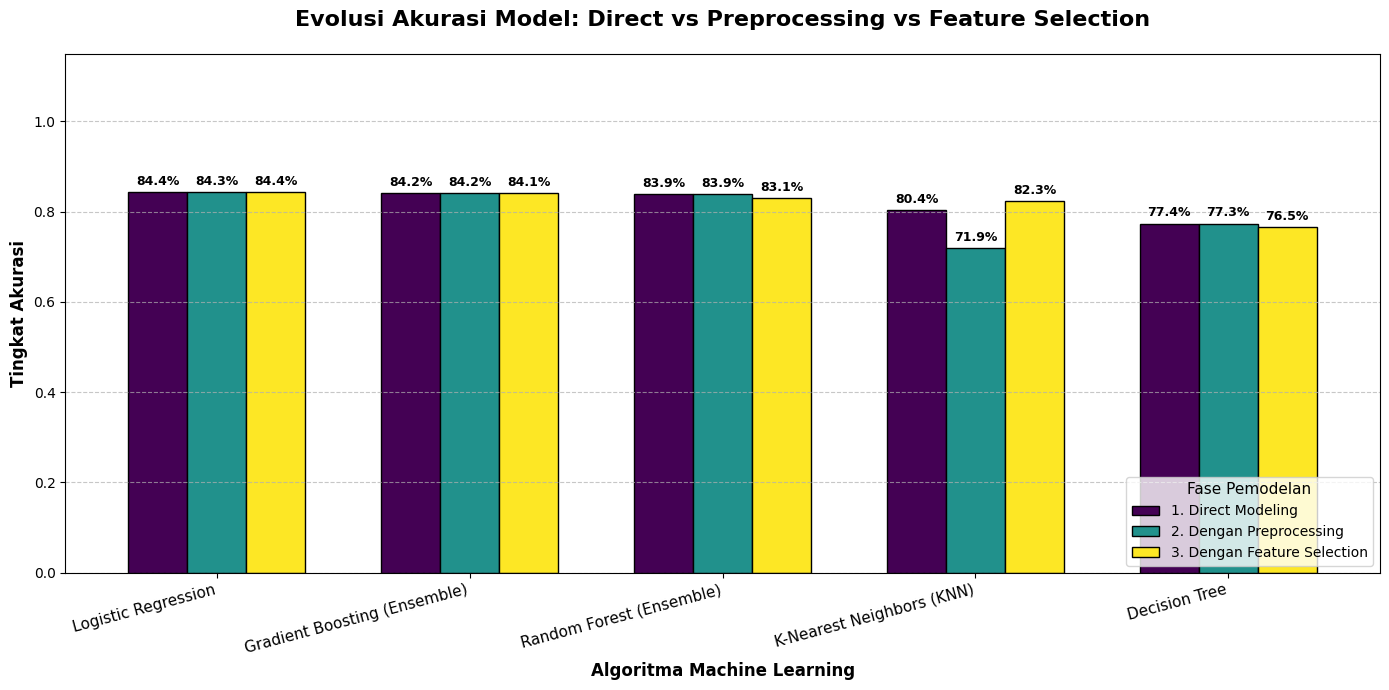

In [30]:
# Menggabungkan ketiga tabel hasil evaluasi berdasarkan nama 'Model'
df_compare = df_results[['Model', 'Accuracy']].merge(
    df_results_pre[['Model', 'Accuracy (Scaled)']], on='Model').merge(
    df_results_sel[['Model', 'Accuracy (Selected)']], on='Model'
)

# Merapikan nama kolom untuk ditampilkan di grafik
df_compare.columns = ['Model', '1. Direct Modeling', '2. Dengan Preprocessing', '3. Dengan Feature Selection']
df_compare.set_index('Model', inplace=True)

# Membuat Visualisasi Bar Chart Bergrup
ax = df_compare.plot(kind='bar', figsize=(14, 7), colormap='viridis', edgecolor='black', width=0.7)

# Menambahkan label persentase di atas setiap bar
for container in ax.containers:
    labels = [f'{val*100:.1f}%' if val > 0 else '' for val in container.datavalues]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9, fontweight='bold')

# Tampilan Grafik
plt.title('Evolusi Akurasi Model: Direct vs Preprocessing vs Feature Selection', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Algoritma Machine Learning', fontsize=12, fontweight='bold')
plt.ylabel('Tingkat Akurasi', fontsize=12, fontweight='bold')
plt.xticks(rotation=15, ha='right', fontsize=11)
plt.ylim(0, 1.15)

plt.legend(title='Fase Pemodelan', loc='lower right', fontsize=10, title_fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Menampilkan grafik
plt.tight_layout()
plt.show()

**Interpretasi Komparasi Model:**  
Berdasarkan visualisasi di atas, terlihat dinamika performa yang beragam, misalnya *K-Nearest Neighbors* (KNN) yang sempat turun drastis saat *preprocessing* akibat sensitivitas terhadap *noise* namun kembali meroket setelah *feature selection*, berbanding terbalik dengan *Decision Tree* yang justru stagnan di tingkat akurasi terendah. Di sisi lain, *Logistic Regression*, *Random Forest*, dan *Gradient Boosting* tampil sangat tangguh dengan akurasi yang stabil di posisi teratas pada ketiga fase pemodelan. Dari model-model terbaik tersebut, *Logistic Regression* dipilih sebagai model final untuk deployment karena meskipun akurasinya bersaing ketat dengan model algoritma kompleks, *Logistic Regression* menawarkan beban komputasi yang jauh lebih ringan serta alur prediksi yang sangat transparan dan mudah dijelaskan.

# Hyperparameter Tuning

In [31]:
# Hyperparameter Tuning: Mengoptimalkan Logistic Regression (Model Terbaik)
base_model = LogisticRegression(random_state=42, max_iter=1000)

# Menentukan parameter yang akan diuji coba secara otomatis
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100], # Kekuatan regulerisasi
    'solver': ['liblinear', 'lbfgs'] # Algoritma optimasi
}

# Inisialisasi GridSearchCV (Mencari parameter terbaik dengan Cross-Validation 5-fold)
grid_search = GridSearchCV(estimator=base_model, param_grid=param_grid,
                           cv=5, scoring='accuracy', n_jobs=-1)

# Melatih grid search menggunakan data latih dengan 10 fitur terbaik
grid_search.fit(X_train_selected, y_train)

# Menampilkan hasil settingan terbaik
print("--- HASIL HYPERPARAMETER TUNING ---")
print(f"Parameter Terbaik: {grid_search.best_params_}")

# Menggunakan model dengan parameter terbaik untuk evaluasi akhir
best_tuned_model = grid_search.best_estimator_
y_pred_final = best_tuned_model.predict(X_test_selected)

print(f"Akurasi Akhir pada Data Uji: {accuracy_score(y_test, y_pred_final):.5f}")
print(f"F1-Score Akhir pada Data Uji: {f1_score(y_test, y_pred_final):.5f}")

--- HASIL HYPERPARAMETER TUNING ---
Parameter Terbaik: {'C': 0.01, 'solver': 'lbfgs'}
Akurasi Akhir pada Data Uji: 0.84320
F1-Score Akhir pada Data Uji: 0.86861


**Hyperparameter Tuning:**  
Berdasarkan evaluasi sebelumnya, Logistic Regression dipilih sebagai model utama karena konsisten memberikan performa tertinggi dan komputasi yang ringan. Untuk memaksimalkan potensinya, dilakukan *Hyperparameter Tuning* menggunakan `GridSearchCV`. Metode ini menguji berbagai kombinasi nilai `C` (parameter regulerisasi) dan `solver` (algoritma optimasi) menggunakan *5-fold Cross-Validation* untuk memastikan model tidak *overfitting*. Hasil keluaran sel ini adalah model paling optimal yang siap digunakan untuk *deployment*.

In [32]:
# Ambil data mentah hanya untuk 10 kolom pilihan saja
X_train_final = X_train[top_10_features]
X_test_final = X_test[top_10_features]

# Buat scaler baru yang khusus belajar dari 10 fitur
scaler_final = StandardScaler()
X_train_scaled_final = scaler_final.fit_transform(X_train_final)
X_test_scaled_final = scaler_final.transform(X_test_final)

# Latih ulang model Logistic Regression (dengan parameter terbaik) menggunakan data yang sudah 100% sinkron
best_tuned_model.fit(X_train_scaled_final, y_train)

# Menyimpan model, scaler, dan daftar fitur ke dalam file
joblib.dump(best_tuned_model, 'model_depresi_fasttrack.pkl')
joblib.dump(scaler_final, 'scaler_fasttrack.pkl')
joblib.dump(top_10_features, 'fitur_pilihan.pkl')

print("BERHASIL! File model, scaler, dan daftar fitur sudah disimpan di Colab.")

BERHASIL! File model, scaler, dan daftar fitur sudah disimpan di Colab.


**Ekspor Model untuk Deployment:**  
Agar aplikasi web berbasis Streamlit dapat melakukan prediksi, model yang telah dilatih harus diekspor terlebih dahulu. Pada tahap ini, *library* `joblib` digunakan untuk menyimpan objek model terbaik (`.pkl`), metode *scaling* yang digunakan, serta daftar 10 fitur terpilih. File-file inilah yang akan menjadi "otak" di balik antarmuka aplikasi Streamlit yang akan dibangun selanjutnya.